# Skill Demand: Shared Foundations and Role Differentiators

## Decision Question

Which skills create broad access to India's largest data-role families, and which skills distinguish one role from another?

Skill demand is measured as **posting prevalence**: the share of postings in a role that mention a skill. This avoids confusing the number of skill mentions with the number of opportunities.

Prevalence = postings mentioning a skill ÷ total postings within the role.

In [1]:
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from matplotlib.patches import Patch
from collections import Counter
from itertools import combinations

In [2]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])


def parse_skills(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    if isinstance(value, list):
        return value
    return []


df["job_skills"] = df["job_skills"].apply(parse_skills)

india_jobs = df[df["job_country"] == "India"].copy()

print(f"Total dataset postings: {len(df):,}")
print(f"India postings: {len(india_jobs):,}")
print(f"Analysis year: {india_jobs['job_posted_date'].dt.year.mode()[0]}")

assert not india_jobs.empty
assert india_jobs["job_country"].eq("India").all()
assert india_jobs["job_posted_date"].dt.year.nunique() == 1

Total dataset postings: 785,741
India postings: 51,088
Analysis year: 2023


In [3]:
def skill_prevalence(jobs, segment="job_title_short"):
    """
    Calculate posting-level skill prevalence within a segment.

    Prevalence =
    postings mentioning a skill /
    total postings within the segment.

    Returns one row per (segment, skill) pair.
    """

    segment_totals = (
        jobs[segment]
        .value_counts()
        .rename("segment_postings")
    )

    skills = (
        jobs.explode("job_skills")
        .groupby([segment, "job_skills"])
        .size()
        .rename("skill_postings")
        .reset_index()
        .join(segment_totals, on=segment)
    )

    skills["prevalence"] = (
        skills["skill_postings"]
        / skills["segment_postings"]
    )

    assert skills["prevalence"].between(0, 1).all()

    return skills

In [4]:
# Notebook-wide visualization settings

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "figure.dpi": 110
})

In [5]:
TOP_ROLE_COUNT = 3

core_roles = (
    india_jobs["job_title_short"]
    .value_counts()
    .head(TOP_ROLE_COUNT)
    .index
    .tolist()
)

core_market = (
    india_jobs[
        india_jobs["job_title_short"].isin(core_roles)
    ]
    .copy()
)

assert len(core_roles) == TOP_ROLE_COUNT
assert set(core_market["job_title_short"].unique()) == set(core_roles)

prevalence = skill_prevalence(core_market)

print(
    f"Core role families: {', '.join(core_roles)}"
)

print(
    f"Coverage: {len(core_market):,} postings "
    f"({len(core_market) / len(india_jobs):.1%} of India market)"
)

assert not prevalence.empty
assert prevalence["prevalence"].between(0, 1).all()

Core role families: Data Engineer, Data Scientist, Data Analyst
Coverage: 38,462 postings (75.3% of India market)


## Cross-Role Skill Architecture

The heatmap compares skill prevalence across the three largest data-role families in India. Skills with consistently high prevalence represent a shared foundation, while large differences in prevalence highlight role-specific capabilities.

Heatmap scope: 13 skills across 3 role families


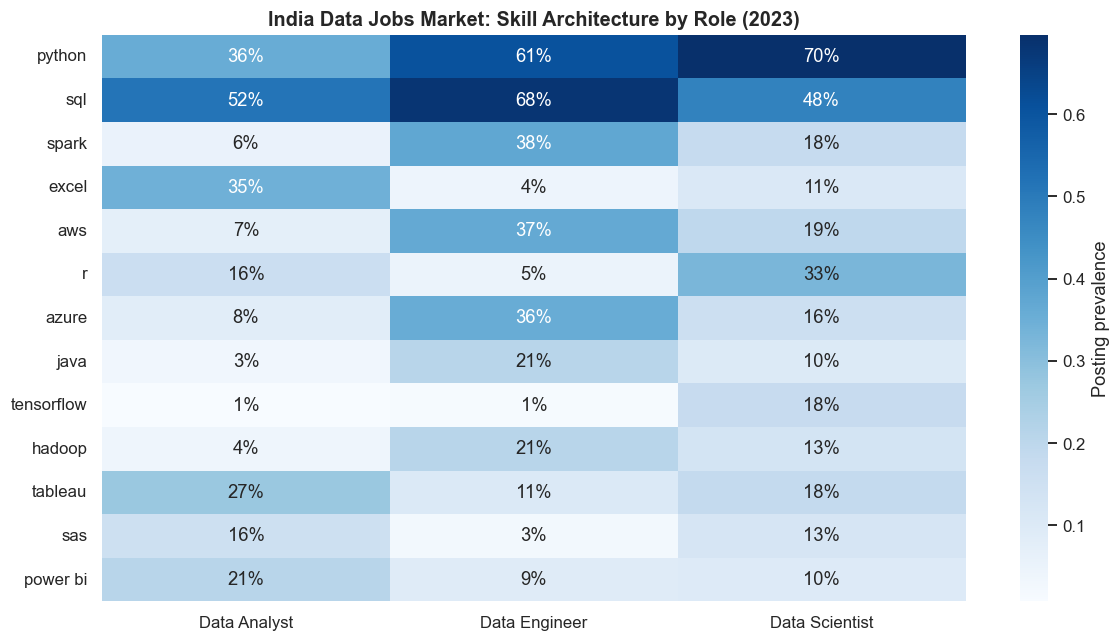

In [6]:
TOP_SKILLS_PER_ROLE = 7  # balances readability and coverage

top_skills = (
    prevalence
    .sort_values(
        ["job_title_short", "prevalence"],
        ascending=[True, False]
    )
    .groupby("job_title_short")
    .head(TOP_SKILLS_PER_ROLE)["job_skills"]
    .unique()
)

skill_matrix = (
    prevalence[
        prevalence["job_skills"].isin(top_skills)
    ]
    .pivot(
        index="job_skills",
        columns="job_title_short",
        values="prevalence"
    )
    .fillna(0)
)

# Preserve universally important foundation skills at the top
core_skills = ["python", "sql"]

core_matrix = skill_matrix.loc[
    [skill for skill in core_skills if skill in skill_matrix.index]
]

# Rank remaining skills by cross-role differentiation
remaining_matrix = skill_matrix.drop(
    index=core_skills,
    errors="ignore"
)

remaining_matrix["spread"] = (
    remaining_matrix.max(axis=1)
    - remaining_matrix.min(axis=1)
)

remaining_matrix = (
    remaining_matrix
    .sort_values("spread", ascending=False)
    .drop(columns="spread")
)

skill_matrix = pd.concat(
    [core_matrix, remaining_matrix]
)

assert not skill_matrix.empty
assert skill_matrix.shape[1] == TOP_ROLE_COUNT
assert skill_matrix.max().max() <= 1
assert skill_matrix.min().min() >= 0

print(
    f"Heatmap scope: {len(skill_matrix)} skills "
    f"across {TOP_ROLE_COUNT} role families"
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    skill_matrix,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    cbar_kws={"label": "Posting prevalence"}
)

plt.title(
    "India Data Jobs Market: Skill Architecture by Role (2023)"
)

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

SQL is the most broadly shared skill across the three core data-role families. Python is similarly cross-functional, appearing in all three roles, but its prevalence is substantially higher in Data Science and Data Engineering than in Data Analysis. As a result, Python is foundational across the ecosystem, but its intensity of demand rises substantially in Data Engineering and Data Science.

The surrounding stack separates the roles: cloud and distributed-computing tools characterize Data Engineering; R and modeling frameworks distinguish Data Science; Excel and business-intelligence platforms distinguish Data Analysis. Demonstrating only SQL and Python signals baseline relevance, while role-specific tools provide the clearest signal of specialization.

## Role Differentiators

A skill's **prevalence spread** is the difference between its highest and lowest prevalence across the three core roles. A larger spread indicates a stronger role signal.

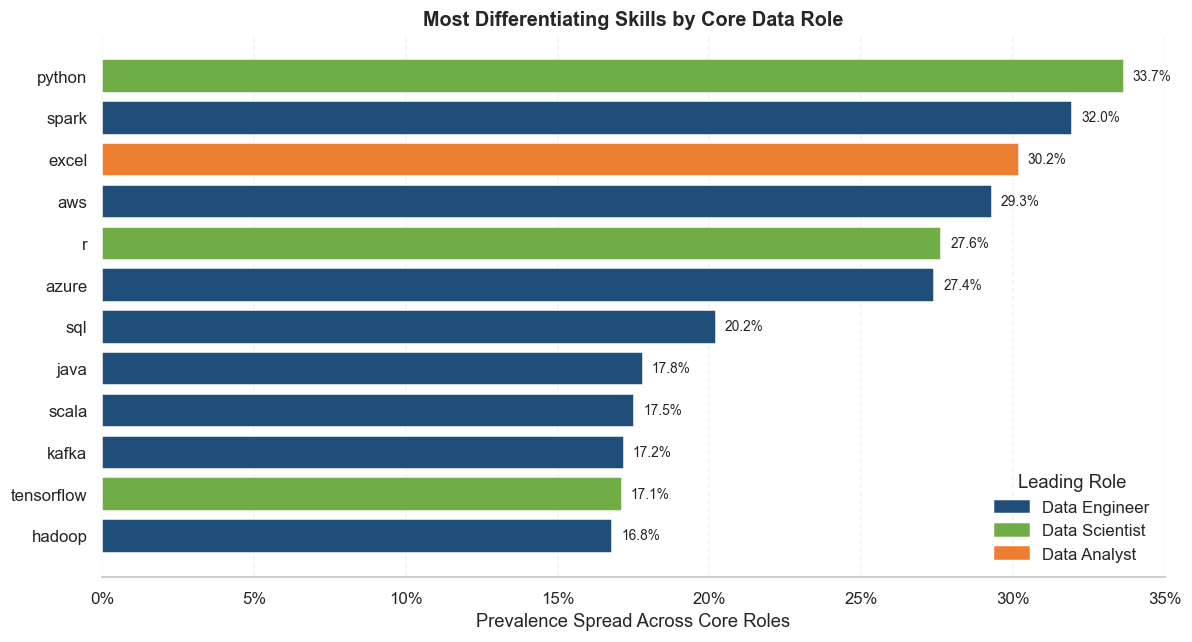

Rank,Skill,Prevalence Spread,Highest Prevalence,Leading Role
1,python,33.7%,69.6%,Data Scientist
2,spark,32.0%,37.5%,Data Engineer
3,excel,30.2%,34.6%,Data Analyst
4,aws,29.3%,36.7%,Data Engineer
5,r,27.6%,32.6%,Data Scientist
6,azure,27.4%,35.8%,Data Engineer
7,sql,20.2%,68.2%,Data Engineer
8,java,17.8%,21.1%,Data Engineer
9,scala,17.5%,19.2%,Data Engineer
10,kafka,17.2%,18.2%,Data Engineer


In [7]:
full_matrix = prevalence.pivot(
    index="job_skills",
    columns="job_title_short",
    values="prevalence"
).fillna(0)

role_signal = pd.DataFrame(
    {
        "spread": full_matrix.max(axis=1) - full_matrix.min(axis=1),
        "peak_prevalence": full_matrix.max(axis=1),
        "leading_role": full_matrix.idxmax(axis=1),
    }
)

role_signal = (
    role_signal[role_signal["peak_prevalence"] >= 0.10]
    .nlargest(12, "spread")
    .sort_values("spread", ascending=False)
)

role_colors = {
    "Data Engineer": "#1F4E79",   # Blue
    "Data Scientist": "#70AD47",  # Green
    "Data Analyst": "#ED7D31",    # Orange
}

colors = role_signal["leading_role"].map(role_colors)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    role_signal.index,
    role_signal["spread"],
    color=colors,
)

legend_handles = [
    Patch(color=color, label=role)
    for role, color in role_colors.items()
]

ax.legend(
    handles=legend_handles,
    title="Leading Role",
    frameon=False,
    loc="lower right",
)

for i, value in enumerate(role_signal["spread"]):
    ax.text(
        value + 0.003,
        i,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.invert_yaxis()

ax.set_xlim(0, 0.35)

ax.xaxis.set_major_formatter(
    lambda value, _: f"{value:.0%}"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

ax.grid(
    axis="y",
    visible=False,
)

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set(
    title="Most Differentiating Skills by Core Data Role",
    xlabel="Prevalence Spread Across Core Roles",
    ylabel="",
)

plt.tight_layout()
plt.show()

display_table = (
    role_signal
    .reset_index()
    .rename(
        columns={
            "job_skills": "Skill",
            "spread": "Prevalence Spread",
            "peak_prevalence": "Highest Prevalence",
            "leading_role": "Leading Role",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1)
)

display(
    display_table.style
    .format(
        {
            "Prevalence Spread": "{:.1%}",
            "Highest Prevalence": "{:.1%}",
        }
    )
    .hide(axis="index")
)

Skills with the largest prevalence spread provide the strongest signal of role specialization. Larger spreads indicate that a skill is substantially more associated with one role family than the others.

Data Engineering is distinguished by distributed-computing and cloud technologies such as Spark, AWS, Azure, Hadoop, Kafka, Scala, and Java. Data Science exhibits the highest prevalence for Python, R, and TensorFlow, while R and TensorFlow providing the clearest role-specific signals. Data Analysis is most strongly associated with Excel, reflecting its emphasis on reporting, dashboarding, and stakeholder-facing analytics.

SQL remains one of the most prevalent skills across all three role families. While Data Engineering exhibits the highest SQL prevalence, its widespread adoption across Data Science and Data Analysis makes it a foundational capability rather than a purely role-specific signal.

## Skill Bundles and Co-Occurrence Patterns

Skills are rarely requested in isolation. Employers typically hire for combinations of complementary capabilities rather than individual tools.

Pair prevalence measures how frequently two skills appear together within job postings. High-prevalence bundles reveal the capability combinations most commonly expected by employers and help distinguish foundational tools from complete working skill sets.

The analysis below highlights the most frequently occurring skill pairs across India data jobs.

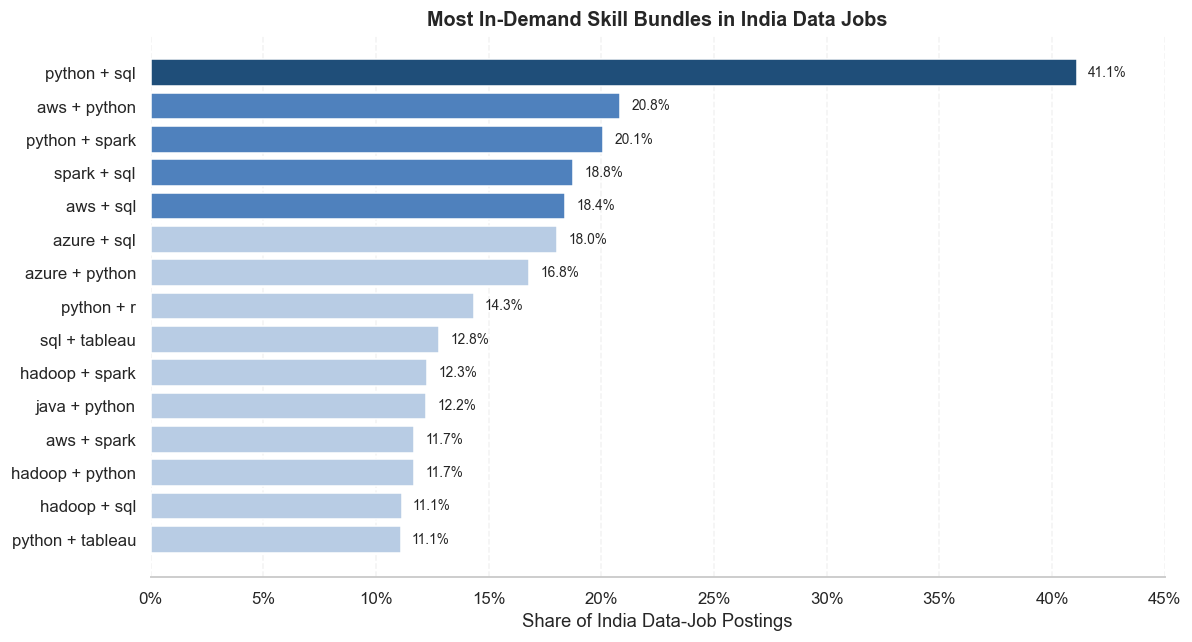

Rank,Skill Bundle,Job Postings,Prevalence Share
1,python + sql,"20,992",41.1%
2,aws + python,"10,642",20.8%
3,python + spark,"10,268",20.1%
4,spark + sql,"9,585",18.8%
5,aws + sql,"9,402",18.4%
6,azure + sql,"9,216",18.0%
7,azure + python,"8,587",16.8%
8,python + r,"7,325",14.3%
9,sql + tableau,"6,535",12.8%
10,hadoop + spark,"6,265",12.3%


In [8]:
pair_counts = Counter(
    pair
    for skills in india_jobs["job_skills"]
    for pair in combinations(sorted(set(skills)), 2)
)

pair_prevalence = (
    pd.DataFrame(
        pair_counts.items(),
        columns=["skill_pair", "postings"]
    )
    .assign(
        prevalence=lambda x: x["postings"] / len(india_jobs),
        skill_pair=lambda x: x["skill_pair"].map(" + ".join)
    )
    .sort_values("prevalence", ascending=False)
    .head(15)
)

colors = (
    ["#1F4E79"] +      # Rank 1
    ["#4F81BD"] * 4 +  # Rank 2–5
    ["#B8CCE4"] * 10   # Rank 6–15
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    pair_prevalence["skill_pair"],
    pair_prevalence["prevalence"],
    color=colors,
)

for i, value in enumerate(pair_prevalence["prevalence"]):
    ax.text(
        value + 0.005,
        i,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.invert_yaxis()

ax.set_xlim(0, 0.45)

ax.xaxis.set_major_formatter(
    lambda value, _: f"{value:.0%}"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

ax.grid(
    axis="y",
    visible=False,
)

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set(
    title="Most In-Demand Skill Bundles in India Data Jobs",
    xlabel="Share of India Data-Job Postings",
    ylabel="",
)

plt.tight_layout()
plt.show()

display_table = (
    pair_prevalence
    .reset_index(drop=True)
    .rename(
        columns={
            "skill_pair": "Skill Bundle",
            "prevalence": "Prevalence Share",
            "postings": "Job Postings",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1)
)

display(
    display_table.style
    .format(
        {
            "Prevalence Share": "{:.1%}",
            "Job Postings": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

The market's most common skill bundles are centered on Python and SQL, which appear together in over 40% of postings.

Cloud and distributed-computing technologies such as AWS, Azure, and Spark frequently co-occur with Python and SQL, indicating that employers increasingly value end-to-end data capabilities rather than isolated tool proficiency.

The prevalence of recurring bundles suggests that hiring demand is structured around capability bundles. Candidates are typically expected to combine data manipulation, querying, and platform technologies within a single role rather than specialize in a single tool.

## Implications

- **For broad market access:** SQL and Python have the highest cross-role portability.
- **For role specialization:** add a stack that matches the work—cloud and Spark for Engineering, modeling tools for Data Science, or BI and spreadsheet tools for Analysis.
- **For capability development:** focus on building skill bundles rather than collecting isolated tools. The most common hiring patterns combine Python and SQL with cloud or distributed-computing technologies, suggesting that employers value integrated workflows more than individual technical competencies.

## Limitations

Skill mentions indicate stated requirements, not depth of proficiency. Missing skill lists and inconsistent terminology can understate prevalence. Co-occurrence shows association within postings, not that every listed skill is essential.